# 01 â€” Exploratory Data Analysis
**SPENDLY Credit Card Transactions (India)**  
Run this notebook _before_ writing any model code.  
All plots save to `notebooks/figures/` so they can be dropped into the final report.

In [18]:
import sys
sys.path.insert(0, '../src')   # so we can import preprocess.py helpers

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Consistent plot style across the project
sns.set_theme(style='darkgrid', font_scale=1.15)
import matplotlib as mpl
mpl.rcParams.update({
    'axes.facecolor': '#1E1E2E',
    'figure.facecolor': '#1E1E2E',
    'axes.edgecolor': '#2C2C3E',
    'axes.labelcolor': '#CDD6F4',
    'text.color': '#CDD6F4',
    'xtick.color': '#A6ADC8',
    'ytick.color': '#A6ADC8',
    'grid.color': '#313244',
    'grid.alpha': 0.5,
    'axes.titleweight': 'bold',
    'axes.titlepad': 15,
    'axes.spines.top': False,
    'axes.spines.right': False
})
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1  Load Raw Data

In [19]:
RAW_PATH = '../data/raw/Credit card transactions - India - Simple.csv'
df_raw = pd.read_csv(RAW_PATH)

# Parse dates immediately for EDA use
df_raw['Date'] = pd.to_datetime(df_raw['Date'], dayfirst=True)

print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (26052, 7)


,index,City,Date,Card Type,Exp Type,Gender,Amount
0,0,"Delhi, India",2014-10-29,Gold,Bills,F,82475
1,1,"Greater Mumbai, India",2014-08-22,Platinum,Bills,F,32555
2,2,"Bengaluru, India",2014-08-27,Silver,Bills,F,101738
3,3,"Greater Mumbai, India",2014-04-12,Signature,Bills,F,123424
4,4,"Bengaluru, India",2015-05-05,Gold,Bills,F,171574


## 2  Data Quality Check

In [20]:
print('=== Data Types ===')
print(df_raw.dtypes)
print()
print('=== Missing Values ===')
print(df_raw.isnull().sum())
print()
print(f'=== Duplicate Rows: {df_raw.duplicated().sum()} ===')

=== Data Types ===
index                 int64
City                 object
Date         datetime64[ns]
Card Type            object
Exp Type             object
Gender               object
Amount                int64
dtype: object

=== Missing Values ===
index        0
City         0
Date         0
Card Type    0
Exp Type     0
Gender       0
Amount       0
dtype: int64

=== Duplicate Rows: 0 ===


## 3  Basic Statistics

In [21]:
print('=== Numeric Summary ===')
display(df_raw[['Amount']].describe().round(2))

print()
for col in ['Card Type', 'Exp Type', 'Gender']:
    print(f'=== {col} Value Counts ===')
    print(df_raw[col].value_counts())
    print()

=== Numeric Summary ===


,Amount
count,26052.00
mean,156411.54
std,103063.25
min,1005.00
25%,77120.25
50%,153106.50
75%,228050.00
max,998077.00



=== Card Type Value Counts ===
Card Type
Silver       6840
Signature    6447
Platinum     6398
Gold         6367
Name: count, dtype: int64

=== Exp Type Value Counts ===
Exp Type
Food             5463
Fuel             5257
Bills            5078
Entertainment    4762
Grocery          4754
Travel            738
Name: count, dtype: int64

=== Gender Value Counts ===
Gender
F    13680
M    12372
Name: count, dtype: int64



In [22]:
print(f'Date range: {df_raw["Date"].min().date()}  â†’  {df_raw["Date"].max().date()}')
print(f'Unique cities: {df_raw["City"].nunique()}')
print(f'Total transactions: {len(df_raw):,}')

Date range: 2013-10-04  â†’  2015-05-26
Unique cities: 986
Total transactions: 26,052


## 4  Amount Distribution

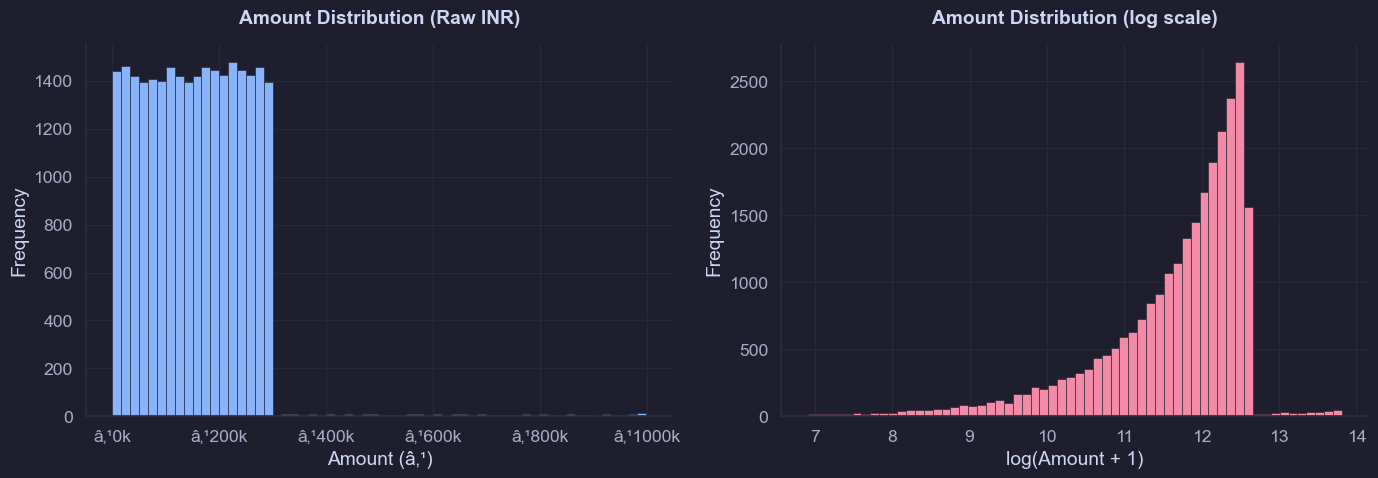

Note: Amount is roughly uniform across â‚¹1kâ€“â‚¹1M with a slight right skew.
No extreme outliers detected â€” min-max normalisation is safe to apply.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df_raw['Amount'], bins=60, color='#89B4FA', edgecolor='#1E1E2E', linewidth=0.4)
axes[0].set_title('Amount Distribution (Raw INR)')
axes[0].set_xlabel('Amount (â‚¹)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'â‚¹{x/1000:.0f}k'))

# Log-scale to reveal shape
axes[1].hist(np.log1p(df_raw['Amount']), bins=60, color='#F38BA8', edgecolor='#1E1E2E', linewidth=0.4)
axes[1].set_title('Amount Distribution (log scale)')
axes[1].set_xlabel('log(Amount + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(FIG_DIR / 'amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretation note for teammates
print('Note: Amount is roughly uniform across â‚¹1kâ€“â‚¹1M with a slight right skew.')
print('No extreme outliers detected â€” min-max normalisation is safe to apply.')

## 5  Expense Type Distribution  *(Target Label â€” Person 2)*

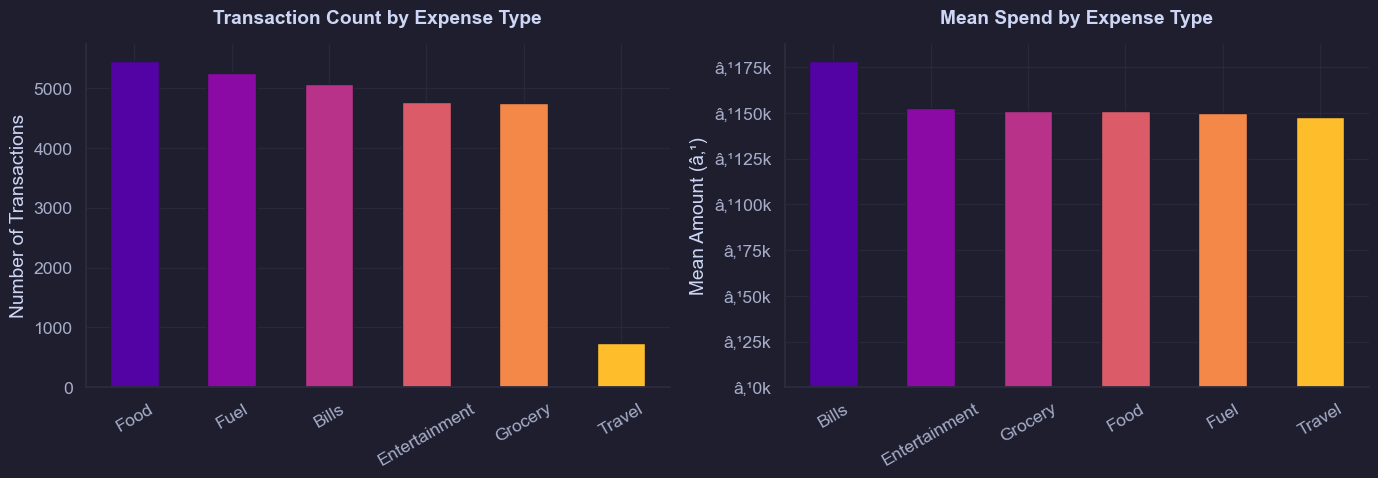

Class balance (%):
Exp Type
Food             21.0
Fuel             20.2
Bills            19.5
Entertainment    18.3
Grocery          18.2
Travel            2.8
Name: count, dtype: float64

â†’ Classes are fairly balanced; no oversampling needed.


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count
exp_counts = df_raw['Exp Type'].value_counts()
exp_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('plasma', len(exp_counts)),
                edgecolor='#1E1E2E')
axes[0].set_title('Transaction Count by Expense Type')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=30)

# Mean amount
mean_amounts = df_raw.groupby('Exp Type')['Amount'].mean().sort_values(ascending=False)
mean_amounts.plot(kind='bar', ax=axes[1], color=sns.color_palette('plasma', len(mean_amounts)),
                  edgecolor='#1E1E2E')
axes[1].set_title('Mean Spend by Expense Type')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean Amount (â‚¹)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'â‚¹{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'expense_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Class balance check for Person 2 (classifier)
print('Class balance (%):')
print((exp_counts / len(df_raw) * 100).round(1))
print('\nâ†’ Classes are fairly balanced; no oversampling needed.')

## 6  Spending Over Time  *(Useful for LSTM â€” Person 4)*

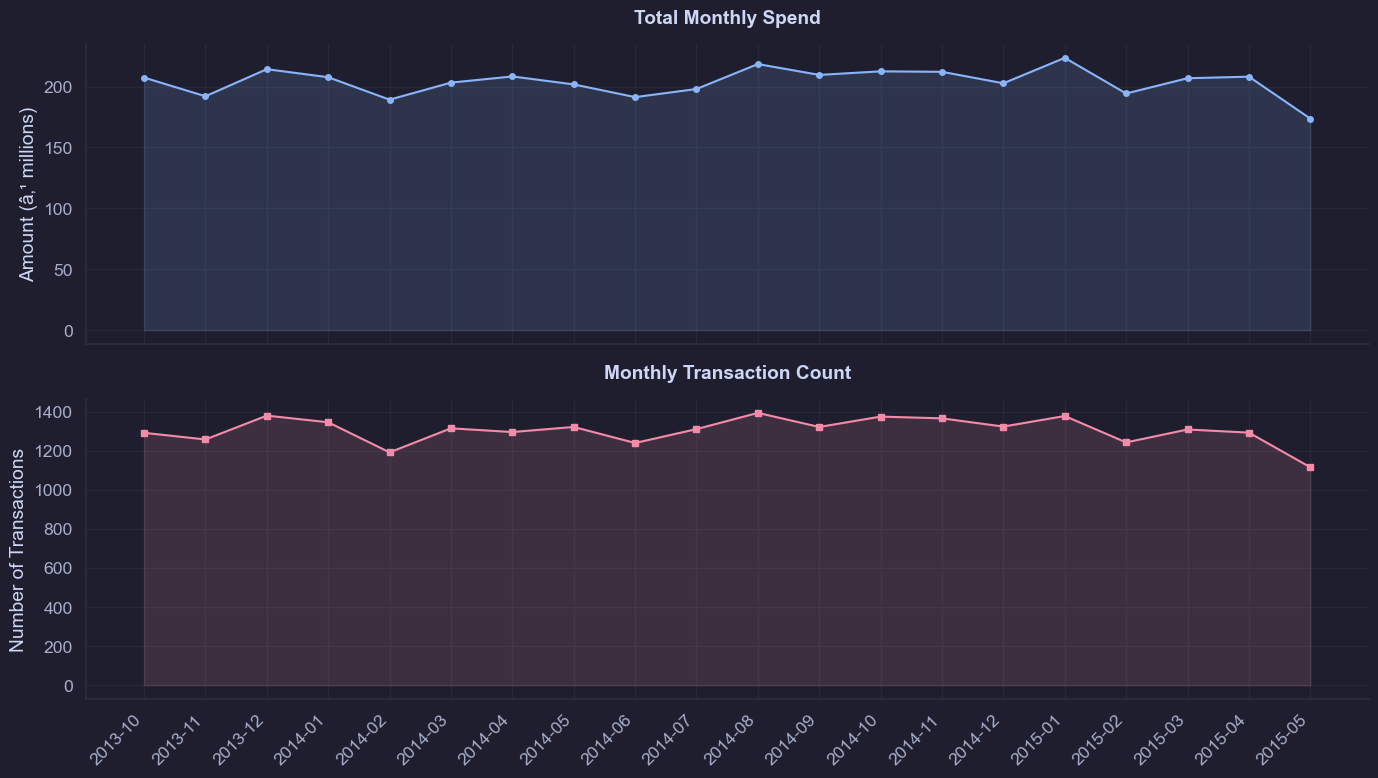

Dataset spans 20 months.


In [25]:
monthly = (
    df_raw
    .assign(YearMonth=df_raw['Date'].dt.to_period('M'))
    .groupby('YearMonth')['Amount']
    .agg(['sum', 'count'])
    .reset_index()
)
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(monthly['YearMonth'], monthly['sum'] / 1e6, marker='o', markersize=4,
             color='#89B4FA', linewidth=1.5)
axes[0].set_title('Total Monthly Spend')
axes[0].set_ylabel('Amount (â‚¹ millions)')
axes[0].fill_between(monthly['YearMonth'], monthly['sum'] / 1e6, alpha=0.15, color='#89B4FA')

axes[1].plot(monthly['YearMonth'], monthly['count'], marker='s', markersize=4,
             color='#F38BA8', linewidth=1.5)
axes[1].set_title('Monthly Transaction Count')
axes[1].set_ylabel('Number of Transactions')
axes[1].fill_between(monthly['YearMonth'], monthly['count'], alpha=0.15, color='#F38BA8')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Dataset spans {monthly.shape[0]} months.')

## 7  Categorical Breakdown

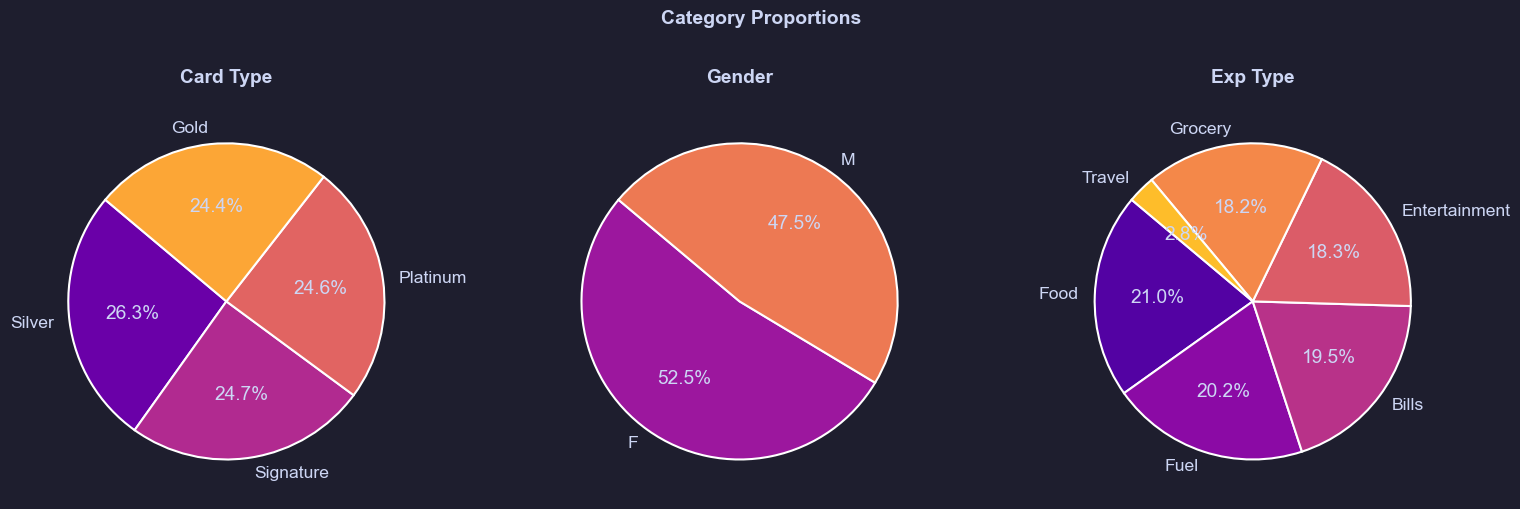

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['Card Type', 'Gender', 'Exp Type']):
    counts = df_raw[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
           colors=sns.color_palette('plasma', len(counts)),
           startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax.set_title(col)

plt.suptitle('Category Proportions', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'category_proportions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8  Amount by Category (Boxplot)

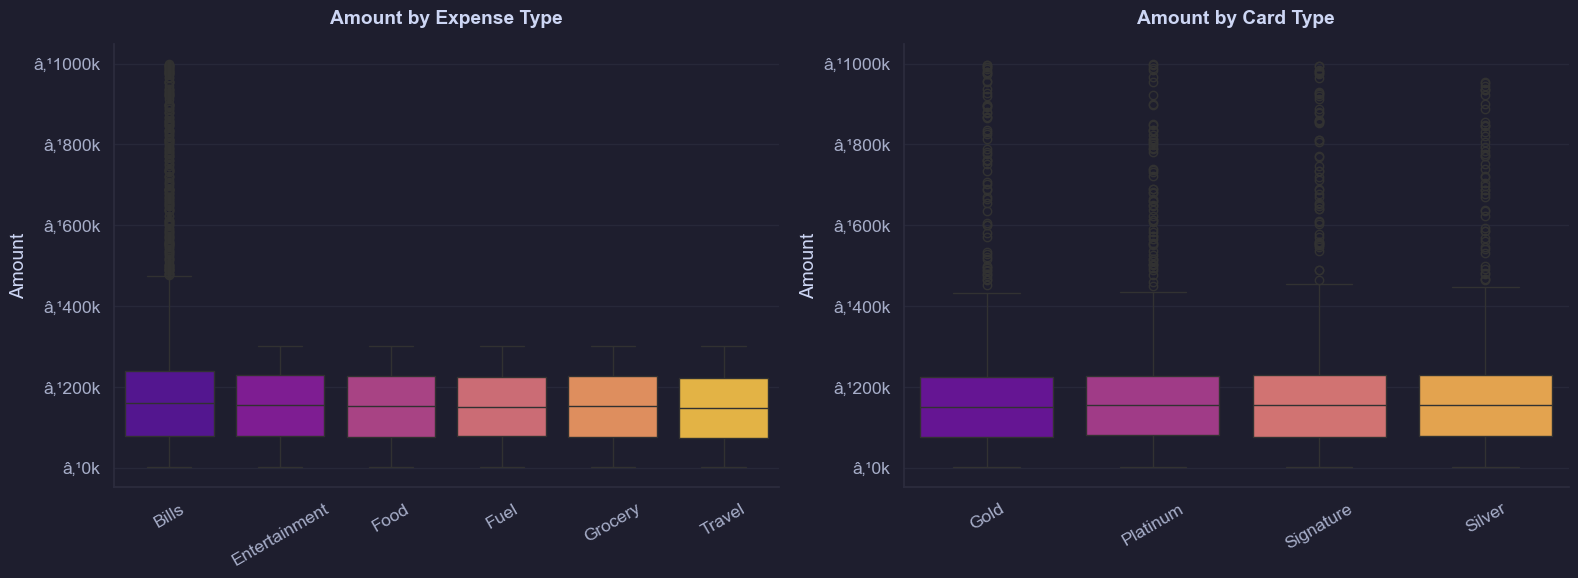

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_raw, x='Exp Type', y='Amount', ax=axes[0],
            palette='plasma', order=sorted(df_raw['Exp Type'].unique()))
axes[0].set_title('Amount by Expense Type')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'â‚¹{x/1000:.0f}k'))
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_raw, x='Card Type', y='Amount', ax=axes[1],
            palette='plasma', order=sorted(df_raw['Card Type'].unique()))
axes[1].set_title('Amount by Card Type')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'â‚¹{x/1000:.0f}k'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(FIG_DIR / 'amount_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

## 9  Correlation Heatmap (Post-Encoding Preview)

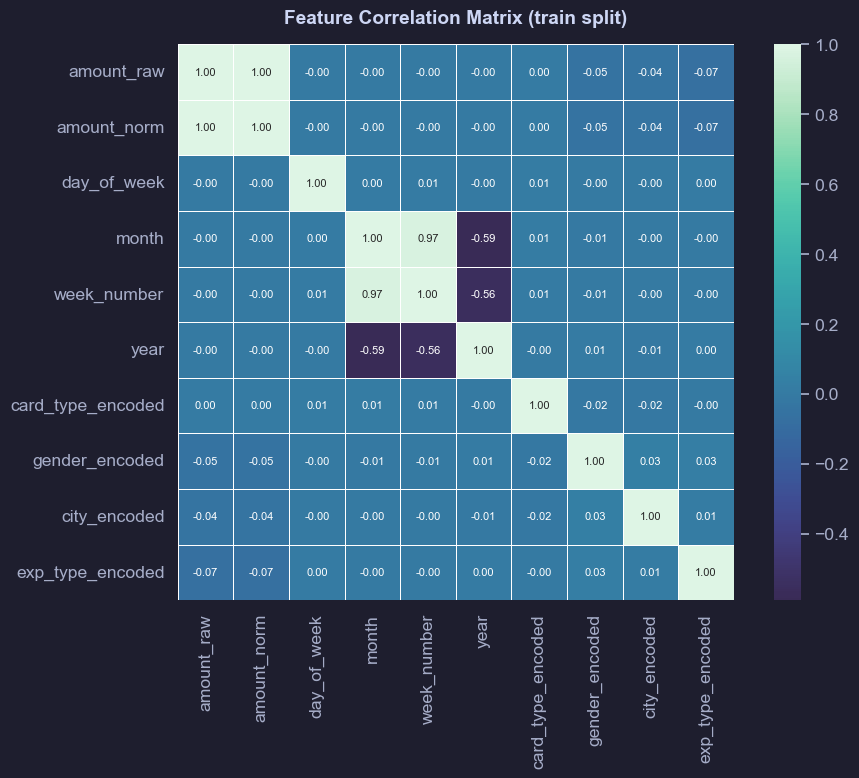

In [28]:
# Load the processed train split (run preprocess.py first)
try:
    train = pd.read_csv('../data/processed/train.csv')
    numeric_cols = [
        'amount_raw', 'amount_norm', 'day_of_week', 'month',
        'week_number', 'year', 'card_type_encoded',
        'gender_encoded', 'city_encoded', 'exp_type_encoded'
    ]
    corr = train[numeric_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='mako', center=0,
                linewidths=0.5, square=True, ax=ax,
                annot_kws={'size': 8})
    ax.set_title('Feature Correlation Matrix (train split)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
except FileNotFoundError:
    print('Run  python src/preprocess.py  first to generate train.csv, then re-run this cell.')

## 10  Top 15 Cities by Spend

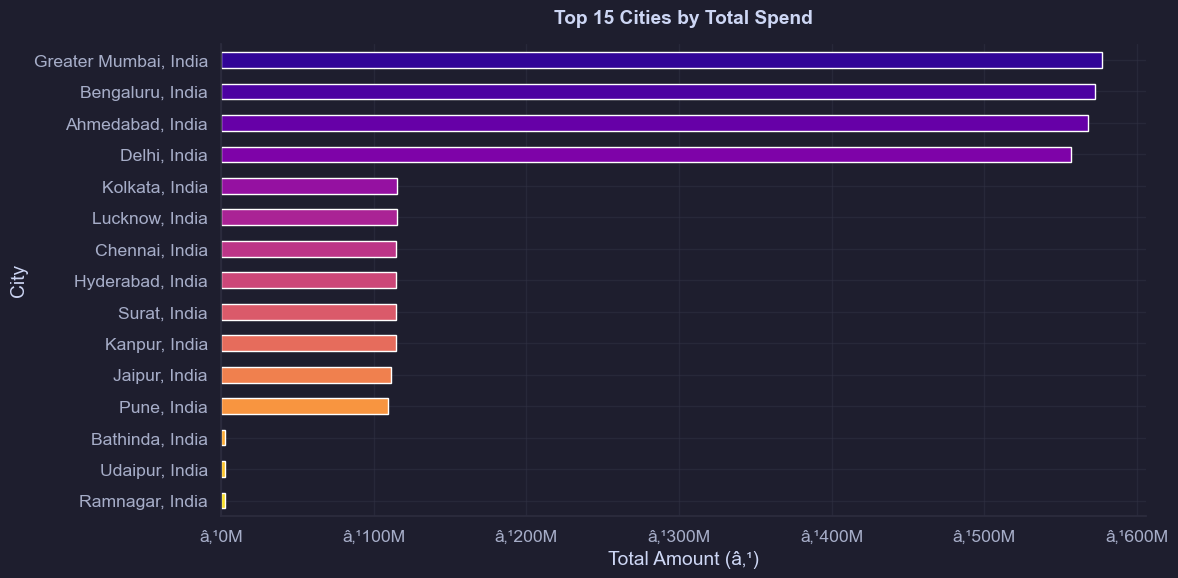

In [29]:
top_cities = (
    df_raw.groupby('City')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
top_cities.plot(kind='barh', ax=ax, color=sns.color_palette('plasma', 15))
ax.set_title('Top 15 Cities by Total Spend')
ax.set_xlabel('Total Amount (â‚¹)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'â‚¹{x/1e6:.0f}M'))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / 'top_cities.png', dpi=150, bbox_inches='tight')
plt.show()

## 11  Train / Val / Test Split Verification

In [30]:
try:
    train = pd.read_csv('../data/processed/train.csv')
    val   = pd.read_csv('../data/processed/val.csv')
    test  = pd.read_csv('../data/processed/test.csv')

    total = len(train) + len(val) + len(test)
    print(f'train : {len(train):>6,} rows  ({len(train)/total*100:.1f}%)')
    print(f'val   : {len(val):>6,} rows  ({len(val)/total*100:.1f}%)')
    print(f'test  : {len(test):>6,} rows  ({len(test)/total*100:.1f}%)')
    print(f'total : {total:>6,} rows')
    print()
    print('train date range:', train['date'].min(), 'â†’', train['date'].max())
    print('val   date range:', val['date'].min(),   'â†’', val['date'].max())
    print('test  date range:', test['date'].min(),  'â†’', test['date'].max())
    print()
    print('No overlap?', train['date'].max() <= val['date'].min())
    print('Columns:', list(train.columns))
except FileNotFoundError:
    print('Run  python src/preprocess.py  first.')

train : 18,236 rows  (70.0%)
val   :  3,908 rows  (15.0%)
test  :  3,908 rows  (15.0%)
total : 26,052 rows

train date range: 2013-10-04 â†’ 2014-11-27
val   date range: 2014-11-27 â†’ 2015-02-24
test  date range: 2015-02-24 â†’ 2015-05-26

No overlap? True
Columns: ['city', 'date', 'card_type', 'exp_type', 'gender', 'amount_raw', 'amount_norm', 'day_of_week', 'month', 'week_number', 'year', 'card_type_encoded', 'gender_encoded', 'city_encoded', 'exp_type_encoded']
